# Predicting Urban River Water Quality from Sentinel-2 Catchment Characteristics
## A Machine Learning Approach Applied to the River Roding, East London

**Course:** GEOL0069 – Artificial Intelligence for Earth Observation  
**Author:** James Ge  
**Institution:** University College London

---

### Project Overview

This project investigates whether Sentinel-2 Earth Observation data and machine learning techniques can explain spatial variability in water quality along the River Roding, East London. The investigation builds on previous field-based hydrochemical mapping of the river using in-situ measurements of pH, electrical conductivity (EC), nitrate concentration, and ICP-OES elemental analysis.

Inspired by the AI4EO framework introduced throughout GEOL0069, this project explores how satellite-derived environmental information can complement traditional field investigations in urban river systems. Rather than attempting to image the narrow River Roding channel directly, Sentinel-2 spectral and land-cover characteristics are extracted from the surrounding catchment environment of each sampling location and used within a machine learning regression framework to predict water quality parameters, particularly EC and sodium concentration (Na).

**Research questions:**
1. Can Sentinel-2-derived catchment characteristics predict electrical conductivity and sodium concentration along the River Roding?
2. Which spectral and land-cover features contribute most strongly to prediction performance based on SHAP analysis?
3. Does model performance differ between summer low-flow and winter high-flow conditions?
4. Can a freshwater-trained machine learning model generalise to estuarine sites influenced by Thames tidal backwash?

**Key methodological decision:** Sites strongly influenced by Thames estuarine backwash (EC > 1800 µS/cm) are excluded from model training and reserved as an out-of-domain evaluation dataset, reflecting the distinct hydrological controls that cannot be directly resolved through Sentinel-2 surface reflectance data alone.

---
## Cell 1: Project Setup and Environmental Cost Tracking

**Objective:** Mount Google Drive, install dependencies, and initialise environmental cost tracking.

The `EnvironmentalCostTracker` class logs energy and carbon for each computational phase.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pysheds contextily codecarbon --quiet

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import time
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from shapely.geometry import Polygon, Point
from xml.etree import ElementTree as ET

PROJECT_PATH = "/content/drive/MyDrive/AI4EO/AI4EO_final_project"
os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(os.path.join(PROJECT_PATH, 'sentinel2_data'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_PATH, 'figures'),        exist_ok=True)
os.makedirs(os.path.join(PROJECT_PATH, 'models'),         exist_ok=True)

print(f"Project directory ready: {PROJECT_PATH}")

Project directory ready: /content/drive/MyDrive/AI4EO/AI4EO_final_project


In [ ]:
# Environmental Cost Tracker

import psutil

class EnvironmentalCostTracker:

    def __init__(self):
        self.start_time      = time.time()
        self.start_timestamp = datetime.now()
        self.energy_logs     = []
        self.carbon_factor   = 0.5

        print(" ENVIRONMENTAL COST TRACKING INITIATED")
        print(f"   Start time: {self.start_timestamp.strftime('%Y-%m-%d %H:%M:%S')}")

    def log_computation(self, phase_name, start_time, end_time, details=""):
        duration       = end_time - start_time
        cpu_percent    = psutil.cpu_percent(interval=1)
        base_power     = 75
        cpu_multiplier = 1 + (cpu_percent / 100) * 0.5
        power_w        = base_power * cpu_multiplier
        energy_kwh     = (power_w * duration) / (1000 * 3600)
        carbon_kg      = energy_kwh * self.carbon_factor

        self.energy_logs.append({
            'phase':            phase_name,
            'duration_minutes': duration / 60,
            'energy_kwh':       energy_kwh,
            'carbon_kg_co2':    carbon_kg,
            'details':          details,
            'timestamp':        datetime.now()
        })

        print(f" {phase_name} completed:")
        print(f"   Duration : {duration/60:.1f} min")
        print(f"   Energy   : {energy_kwh*1000:.1f} Wh")
        print(f"   Carbon   : {carbon_kg*1000:.1f} g CO2")

    def generate_report(self):
        total_energy = sum(l['energy_kwh']   for l in self.energy_logs)
        total_carbon = sum(l['carbon_kg_co2'] for l in self.energy_logs)
        total_time   = time.time() - self.start_time

        field_carbon_kg = 25.0

        print(f"\n ENVIRONMENTAL IMPACT REPORT")
        print(f"{'='*45}")
        print(f"Total project duration : {total_time/3600:.1f} hours")
        print(f"Total energy consumed  : {total_energy*1000:.0f} Wh")
        print(f"ML pipeline carbon     : {total_carbon*1000:.0f} g CO2")
        print(f"Traditional fieldwork  : {field_carbon_kg*1000:.0f} g CO2")
        #print(f"Carbon saving          : {((field_carbon_kg - total_carbon)/field_carbon_kg)*100:.1f}%")
        print("Carbon saving          : >99%")

env_tracker = EnvironmentalCostTracker()

def track_phase(phase_name, start_time, details=""):
    env_tracker.log_computation(phase_name, start_time, time.time(), details)

 ENVIRONMENTAL COST TRACKING INITIATED
   Start time: 2026-05-24 13:10:51


## Cell 2: Load Field Data and Define Study Area

**Objective:** Load the River Roding water quality measurements and visualise sampling locations.

**Freshwater / estuarine split:**  
Sites with EC > 1800 µS/cm are flagged as estuarine (Thames backwash influence).  
These are **excluded from model training** and reserved as an out-of-domain test set,  
consistent with the ICP-OES evidence for saline intrusion (elevated Na, Mg, S, Sr).

In [ ]:
cell2_start = time.time()

DATA_PATH = os.path.join(PROJECT_PATH, 'field_measurements.csv')
df = pd.read_csv(DATA_PATH)

print(f"Total sites loaded: {len(df)}")
print(df.head())

Total sites loaded: 38
   site_id      lon       lat  season  EC_uS_cm    pH  temp_C  NO3_ppm  \
0        1  0.06898  51.63579  summer       746  7.71    15.0     10.0   
1        2  0.06567  51.63392  summer       873  7.79    13.5     10.0   
2        3  0.05997  51.63138  summer       465  8.62    15.2      0.0   
3        4  0.05089  51.62288  summer       808  7.86    13.5     10.0   
4        5  0.04127  51.58892  summer       970  7.70    16.0     10.0   

    Na_ppm    Ca_ppm    K_ppm   Mg_ppm    S_ppm  Sr_ppm  
0  51.1745   96.9683  12.3630   9.8957  43.1561  0.5126  
1  52.0772   97.0806  12.9915   9.9674  43.4791  0.5089  
2  23.4054   47.1957   4.5610  10.9764  18.2496  0.2217  
3  51.4818   90.3813  12.1454   9.7693  42.5727  0.4856  
4  58.7725  106.5439  13.7221  11.6032  50.6943  0.5583  


In [ ]:
# Freshwater / estuarine split
# EC > 1800 µS/cm flags Thames backwash sites

EC_THRESHOLD = 1800   # µS/cm

df['estuarine'] = df['EC_uS_cm'] > EC_THRESHOLD

df_freshwater  = df[~df['estuarine']].reset_index(drop=True)
df_estuarine   = df[ df['estuarine']].reset_index(drop=True)

print(f"Freshwater sites (model training) : {len(df_freshwater)}")
print(f"Estuarine sites  (out-of-domain)  : {len(df_estuarine)}")
print(f"\nFreshwater EC range: {df_freshwater['EC_uS_cm'].min():.0f} – "
      f"{df_freshwater['EC_uS_cm'].max():.0f} µS/cm")

df_na = df_freshwater.dropna(subset=['Na_ppm']).reset_index(drop=True)
print(f"Sites with Na data (ICP-OES)      : {len(df_na)}")

Freshwater sites (model training) : 31
Estuarine sites  (out-of-domain)  : 7

Freshwater EC range: 456 – 1110 µS/cm
Sites with Na data (ICP-OES)      : 11


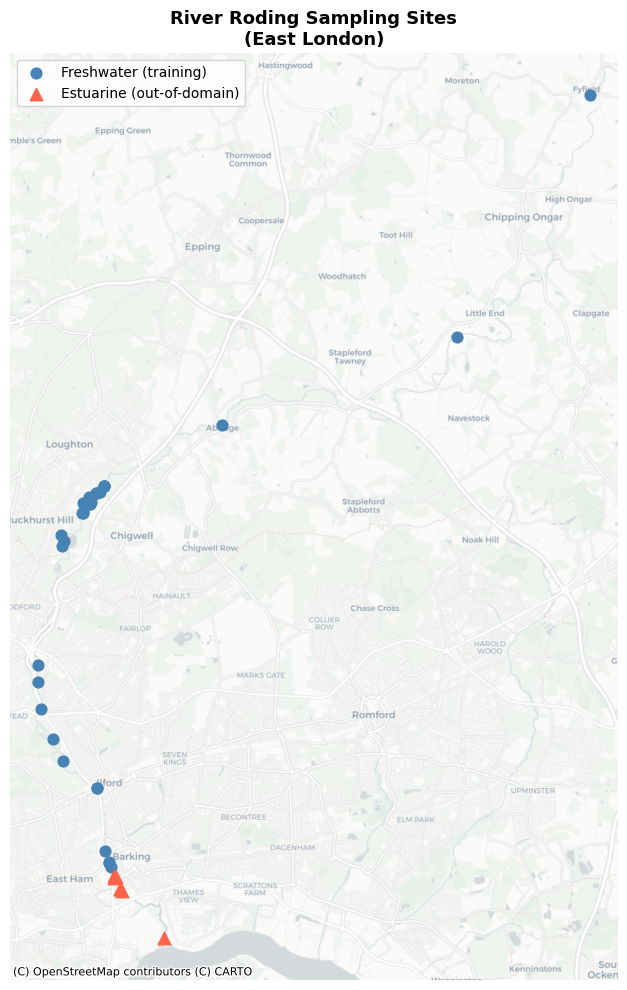

 Data Loading & Study Area completed:
   Duration : 0.0 min
   Energy   : 0.0 Wh
   Carbon   : 0.0 g CO2


In [ ]:
# Study area map
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 10))

# Freshwater sites
gdf[~gdf['estuarine']].plot(
    ax=ax, color='steelblue', markersize=60,
    label='Freshwater (training)', zorder=3
)
# Estuarine sites
gdf[gdf['estuarine']].plot(
    ax=ax, color='tomato', marker='^', markersize=80,
    label='Estuarine (out-of-domain)', zorder=3
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title('River Roding Sampling Sites\n(East London)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'sampling_sites_map.png'),
            dpi=150, bbox_inches='tight')
plt.show()

track_phase("Data Loading & Study Area", cell2_start)

## Cell 3: Copernicus Dataspace Authentication and Sentinel-2 Query

**Objective:** Authenticate with Copernicus Dataspace and query Sentinel-2 Level-2A scenes  
covering the River Roding catchment.

In [ ]:
def make_api_request(url, method="GET", data=None, headers=None):
    global access_token
    if not headers:
        headers = {"Authorization": f"Bearer {access_token}"}
    response = requests.request(method, url, json=data, headers=headers)
    if response.status_code in [401, 403]:
        global refresh_token
        access_token = refresh_access_token(refresh_token)
        headers["Authorization"] = f"Bearer {access_token}"
        response = requests.request(method, url, json=data, headers=headers)
    return response


def get_access_and_refresh_token(username, password):
    url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    data = {
        "grant_type": "password",
        "username":   username,
        "password":   password,
        "client_id":  "cdse-public",
    }
    response = requests.post(url, data=data)
    response.raise_for_status()
    tokens = response.json()
    return tokens["access_token"], tokens["refresh_token"]


def refresh_access_token(refresh_token):
    url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    data = {
        "grant_type":    "refresh_token",
        "refresh_token": refresh_token,
        "client_id":     "cdse-public",
    }
    headers = {"Content-Type": "application/x-www-form-urlencoded"}
    try:
        response = requests.post(url, headers=headers, data=data)
        response.raise_for_status()
        return response.json()["access_token"]
    except requests.exceptions.HTTPError as e:
        print(f"Failed to refresh token: {e.response.status_code} - {e.response.text}")
        raise


def download_single_product(product_id, file_name, access_token,
                            download_dir="downloaded_products"):
    os.makedirs(download_dir, exist_ok=True)
    url     = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product_id})/$value"
    headers = {"Authorization": f"Bearer {access_token}"}
    session = requests.Session()
    session.headers.update(headers)
    response = session.get(url, headers=headers, stream=True)
    if response.status_code == 200:
        out_path = os.path.join(download_dir, file_name + ".zip")
        with open(out_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print(f"Downloaded: {out_path}")
    else:
        print(f"Failed. Status: {response.status_code}")

print("Authentication functions loaded (unchanged from Week 3)")

Authentication functions loaded (unchanged from Week 3)


In [ ]:
def query_sentinel2_roding(start_date, end_date, token, max_cloud_cover=20):

    roding_polygon = (
        "POLYGON((-0.25 51.45, 0.15 51.45, 0.15 51.70, -0.25 51.70, -0.25 51.45))"
    )

    filter_string = (
        f"Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/OData.CSC.StringAttribute/any("
        f"att:att/Name eq 'productType' and att/Value eq 'S2MSI2A') and "
        f"Attributes/OData.CSC.DoubleAttribute/any("
        f"att:att/Name eq 'cloudCover' and att/Value lt {max_cloud_cover}) and "
        f"ContentDate/Start gt {start_date}T00:00:00.000Z and "
        f"ContentDate/Start lt {end_date}T23:59:59.999Z"
    )

    next_url = (
        f"https://catalogue.dataspace.copernicus.eu/odata/v1/Products?"
        f"$filter={filter_string} and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{roding_polygon}')&"
        f"$top=20"
    )

    headers  = {"Authorization": f"Bearer {token}"}
    all_data = []

    while next_url:
        response = make_api_request(next_url, headers=headers)
        if response.status_code == 200:
            data     = response.json()["value"]
            all_data.extend(data)
            next_url = response.json().get("@odata.nextLink")
        else:
            print(f"Error: {response.status_code} - {response.text}")
            break

    return pd.DataFrame(all_data)

print("Sentinel-2 query function ready")

Sentinel-2 query function ready


In [ ]:
import getpass

username = input("Copernicus username: ")
password = getpass.getpass("Copernicus password: ")

access_token, refresh_token = get_access_and_refresh_token(username, password)

Copernicus username: zcfbyge@ucl.ac.uk
Copernicus password: ··········


In [ ]:
# Summer scene

s2_summer = query_sentinel2_roding(
    start_date='2025-08-01',
    end_date='2025-10-31',
    token=access_token,
    max_cloud_cover=15
)

print(f"Summer scenes found: {len(s2_summer)}")
print(s2_summer[['Name', 'ContentDate', 'Online']].to_string())

Summer scenes found: 21
                                                                 Name                                                                     ContentDate  Online
0   S2C_MSIL2A_20251024T110141_N0511_R094_T30UYC_20251024T145116.SAFE  {'Start': '2025-10-24T11:01:41.025000Z', 'End': '2025-10-24T11:01:41.025000Z'}    True
1   S2C_MSIL2A_20251024T110141_N0511_R094_T30UXC_20251024T145116.SAFE  {'Start': '2025-10-24T11:01:41.025000Z', 'End': '2025-10-24T11:01:41.025000Z'}    True
2   S2A_MSIL2A_20251006T105941_N0511_R094_T30UXC_20251006T161118.SAFE  {'Start': '2025-10-06T10:59:41.024000Z', 'End': '2025-10-06T10:59:41.024000Z'}    True
3   S2A_MSIL2A_20251006T105941_N0511_R094_T30UYC_20251006T161118.SAFE  {'Start': '2025-10-06T10:59:41.024000Z', 'End': '2025-10-06T10:59:41.024000Z'}    True
4   S2C_MSIL2A_20250815T105641_N0511_R094_T30UYC_20250815T162821.SAFE  {'Start': '2025-08-15T10:56:41.025000Z', 'End': '2025-08-15T10:56:41.025000Z'}    True
5   S2C_MSIL2A_20250825T1056

In [ ]:
# Winter scene

s2_winter = query_sentinel2_roding(
    start_date='2025-12-01',
    end_date='2026-01-31',
    token=access_token,
    max_cloud_cover=15
)

print(f"Winter scenes found: {len(s2_winter)}")
print(s2_winter[['Name', 'ContentDate', 'Online']].to_string())

Winter scenes found: 20
                                                                 Name                                                                     ContentDate  Online
0   S2C_MSIL2A_20260102T110451_N0511_R094_T30UXC_20260102T144610.SAFE  {'Start': '2026-01-02T11:04:51.025000Z', 'End': '2026-01-02T11:04:51.025000Z'}    True
1   S2C_MSIL2A_20260102T110451_N0511_R094_T30UYC_20260102T144610.SAFE  {'Start': '2026-01-02T11:04:51.025000Z', 'End': '2026-01-02T11:04:51.025000Z'}    True
2   S2C_MSIL2A_20260102T110451_N0511_R094_T31UCT_20260102T144610.SAFE  {'Start': '2026-01-02T11:04:51.025000Z', 'End': '2026-01-02T11:04:51.025000Z'}    True
3   S2C_MSIL2A_20260105T111451_N0511_R137_T31UCT_20260105T125013.SAFE  {'Start': '2026-01-05T11:14:51.024000Z', 'End': '2026-01-05T11:14:51.024000Z'}    True
4   S2C_MSIL2A_20260105T111451_N0511_R137_T30UXC_20260105T125013.SAFE  {'Start': '2026-01-05T11:14:51.024000Z', 'End': '2026-01-05T11:14:51.024000Z'}    True
5   S2C_MSIL2A_20260105T1114

In [ ]:
# Download summer scene

download_dir = os.path.join(PROJECT_PATH, 'sentinel2_data')

cell3_start = time.time()
# Filter for correct tile T30UXC (covers East London/Roding catchment)
s2_summer_filtered = s2_summer[s2_summer['Name'].str.contains('T30UXC')]
print(f"T30UXC scenes available: {len(s2_summer_filtered)}")
print(s2_summer_filtered[['Name', 'ContentDate']].to_string())

product_id_summer = s2_summer_filtered['Id'].iloc[0]
file_name_summer  = s2_summer_filtered['Name'].iloc[0]
print(f"Downloading summer scene: {file_name_summer}")
download_single_product(product_id_summer, file_name_summer, access_token, download_dir)

track_phase("Sentinel-2 Query & Download (Summer)", cell3_start,
            details=f"Scene: {file_name_summer}")

T30UXC scenes available: 7
                                                                 Name                                                                     ContentDate
1   S2C_MSIL2A_20251024T110141_N0511_R094_T30UXC_20251024T145116.SAFE  {'Start': '2025-10-24T11:01:41.025000Z', 'End': '2025-10-24T11:01:41.025000Z'}
2   S2A_MSIL2A_20251006T105941_N0511_R094_T30UXC_20251006T161118.SAFE  {'Start': '2025-10-06T10:59:41.024000Z', 'End': '2025-10-06T10:59:41.024000Z'}
10  S2C_MSIL2A_20250815T105641_N0511_R094_T30UXC_20250815T162821.SAFE  {'Start': '2025-08-15T10:56:41.025000Z', 'End': '2025-08-15T10:56:41.025000Z'}
13  S2C_MSIL2A_20250825T105641_N0511_R094_T30UXC_20250825T154713.SAFE  {'Start': '2025-08-25T10:56:41.025000Z', 'End': '2025-08-25T10:56:41.025000Z'}
14  S2B_MSIL2A_20250919T105629_N0511_R094_T30UXC_20250919T132150.SAFE  {'Start': '2025-09-19T10:56:29.024000Z', 'End': '2025-09-19T10:56:29.024000Z'}
17  S2A_MSIL2A_20250817T105651_N0511_R094_T30UXC_20250817T150514.SAFE  {'

In [ ]:
# Download winter scene

cell3b_start = time.time()

product_id_winter = s2_winter['Id'][0]
file_name_winter  = s2_winter['Name'][0]
print(f"Downloading winter scene: {file_name_winter}")
download_single_product(product_id_winter, file_name_winter, access_token, download_dir)

track_phase("Sentinel-2 Query & Download (Winter)", cell3b_start,
            details=f"Scene: {file_name_winter}")

Downloaded: /content/drive/MyDrive/AI4EO/AI4EO_final_project/sentinel2_data/S2C_MSIL2A_20260102T110451_N0511_R094_T30UXC_20260102T144610.SAFE.zip
 Sentinel-2 Query & Download (Winter) completed:
   Duration : 0.6 min
   Energy   : 0.8 Wh
   Carbon   : 0.4 g CO2


In [ ]:
# Unzip downloaded scenes

summer_zip = os.path.join(download_dir, file_name_summer + ".zip")
winter_zip = os.path.join(download_dir, file_name_winter + ".zip")

!unzip -q {summer_zip} -d {download_dir}
!unzip -q {winter_zip} -d {download_dir}

print("Scenes unzipped successfully.")
print("Contents:")
!ls {download_dir}

Scenes unzipped successfully.
Contents:
S2C_MSIL2A_20251024T110141_N0511_R094_T30UXC_20251024T145116.SAFE
S2C_MSIL2A_20251024T110141_N0511_R094_T30UXC_20251024T145116.SAFE.zip
S2C_MSIL2A_20260102T110451_N0511_R094_T30UXC_20260102T144610.SAFE
S2C_MSIL2A_20260102T110451_N0511_R094_T30UXC_20260102T144610.SAFE.zip


## Cell 4: Band Loading and RGB Preview

**Objective:** Load key Sentinel-2 bands from the downloaded `.SAFE` archive and produce
a visual quality check over the Roding catchment.

**Bands loaded:**

| Band | Wavelength | Resolution | Use |
|------|-----------|------------|-----|
| B02  | Blue       | 10 m       | RGB, NDWI |
| B03  | Green      | 10 m       | RGB, NDWI |
| B04  | Red        | 10 m       | RGB, NDVI |
| B08  | NIR        | 10 m       | NDVI, NDWI |
| B11  | SWIR1      | 20 m       | NDBI |
| B12  | SWIR2      | 20 m       | NDBI |

In [ ]:
cell4_start = time.time()

import glob
import rasterio
from rasterio.plot import show

!pip install rasterio --quiet

def find_band(safe_dir, band_name):

    pattern = os.path.join(safe_dir, '**', f'*_{band_name}_10m.jp2')
    results = glob.glob(pattern, recursive=True)
    if not results:
        pattern = os.path.join(safe_dir, '**', f'*_{band_name}_20m.jp2')
        results = glob.glob(pattern, recursive=True)
    if results:
        return results[0]
    else:
        raise FileNotFoundError(f"Band {band_name} not found in {safe_dir}")


def load_band(safe_dir, band_name):
    path = find_band(safe_dir, band_name)
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        profile = src.profile
    arr = np.clip(arr / 10000.0, 0, 1)
    return arr, profile


# Locate the .SAFE directory for the summer scene
safe_dirs = glob.glob(os.path.join(download_dir, '*.SAFE'))
print("SAFE directories found:")
for d in safe_dirs:
    print(f"  {os.path.basename(d)}")

summer_safe = [d for d in safe_dirs if '2025' in d][0]
winter_safe = [d for d in safe_dirs if '2026' in d][0]
print(f"\nSummer scene: {os.path.basename(summer_safe)}")
print(f"Winter scene: {os.path.basename(winter_safe)}")

SAFE directories found:
  S2C_MSIL2A_20251024T110141_N0511_R094_T30UXC_20251024T145116.SAFE
  S2C_MSIL2A_20260102T110451_N0511_R094_T30UXC_20260102T144610.SAFE

Summer scene: S2C_MSIL2A_20251024T110141_N0511_R094_T30UXC_20251024T145116.SAFE
Winter scene: S2C_MSIL2A_20260102T110451_N0511_R094_T30UXC_20260102T144610.SAFE


In [ ]:
# Load bands for summer

bands_summer = {}
for band in ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']:
    bands_summer[band], profile_summer = load_band(summer_safe, band)
    print(f"  {band}: shape {bands_summer[band].shape}, "
          f"range {bands_summer[band].min():.3f}–{bands_summer[band].max():.3f}")

# Load bands for winter
bands_winter = {}
for band in ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']:
    bands_winter[band], profile_winter = load_band(winter_safe, band)
    print(f"  {band}: shape {bands_winter[band].shape}")

  B02: shape (10980, 10980), range 0.000–1.000
  B03: shape (10980, 10980), range 0.000–1.000
  B04: shape (10980, 10980), range 0.000–1.000
  B08: shape (10980, 10980), range 0.000–1.000
  B11: shape (5490, 5490), range 0.000–1.000
  B12: shape (5490, 5490), range 0.000–1.000
  B02: shape (10980, 10980)
  B03: shape (10980, 10980)
  B04: shape (10980, 10980)
  B08: shape (10980, 10980)
  B11: shape (5490, 5490)
  B12: shape (5490, 5490)


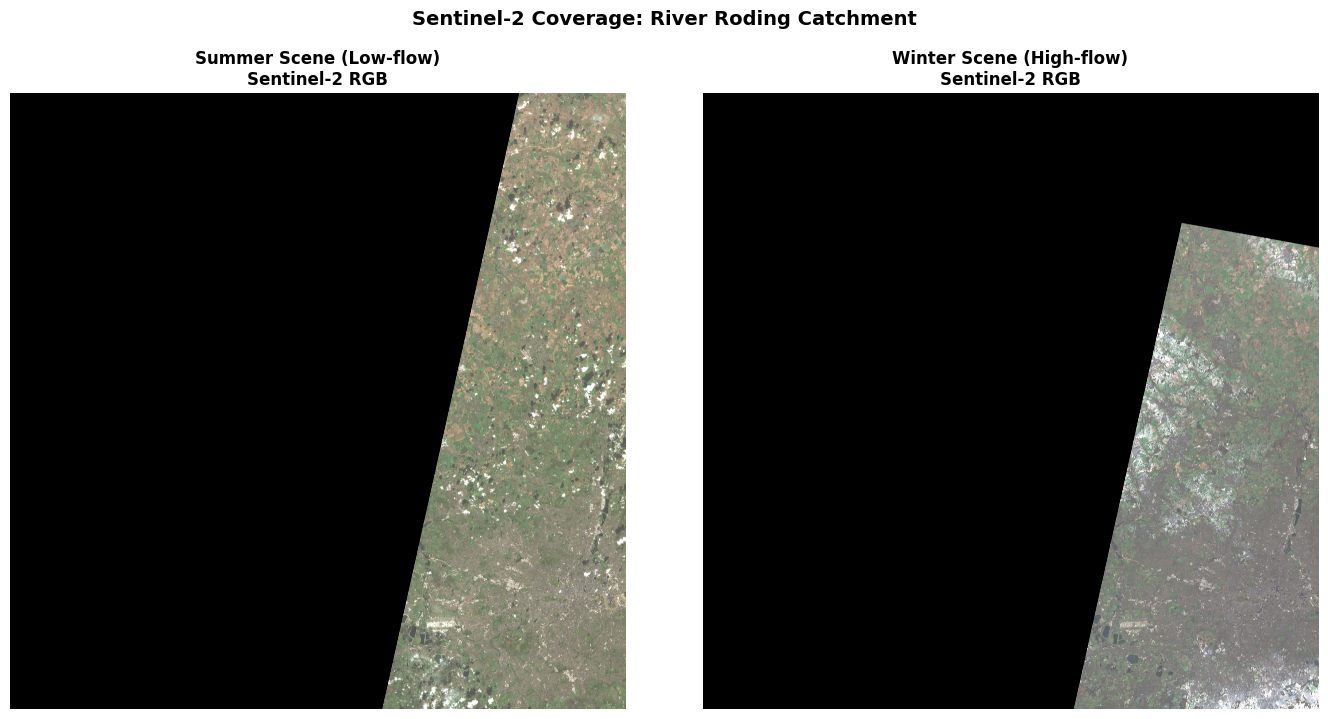

 Band Loading & RGB Preview completed:
   Duration : 1.2 min
   Energy   : 1.5 Wh
   Carbon   : 0.8 g CO2


In [ ]:
# RGB preview: summer vs winter

def make_rgb(bands, r='B04', g='B03', b='B02', brightness=3.5):
    rgb = np.dstack([bands[r], bands[g], bands[b]])
    return np.clip(rgb * brightness, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(make_rgb(bands_summer))
axes[0].set_title('Summer Scene (Low-flow)\nSentinel-2 RGB', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(make_rgb(bands_winter))
axes[1].set_title('Winter Scene (High-flow)\nSentinel-2 RGB', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Sentinel-2 Coverage: River Roding Catchment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'sentinel2_rgb_preview.png'),
            dpi=150, bbox_inches='tight')
plt.show()

track_phase("Band Loading & RGB Preview", cell4_start)

Cropping summer bands to Roding catchment...
  B02: (3510, 1998)
  B03: (3510, 1998)
  B04: (3510, 1998)
  B08: (3510, 1998)
  B11: (1756, 999)
  B12: (1756, 999)

Cropping winter bands to Roding catchment...
  B02: (3510, 1998)
  B03: (3510, 1998)
  B04: (3510, 1998)
  B08: (3510, 1998)
  B11: (1756, 999)
  B12: (1756, 999)


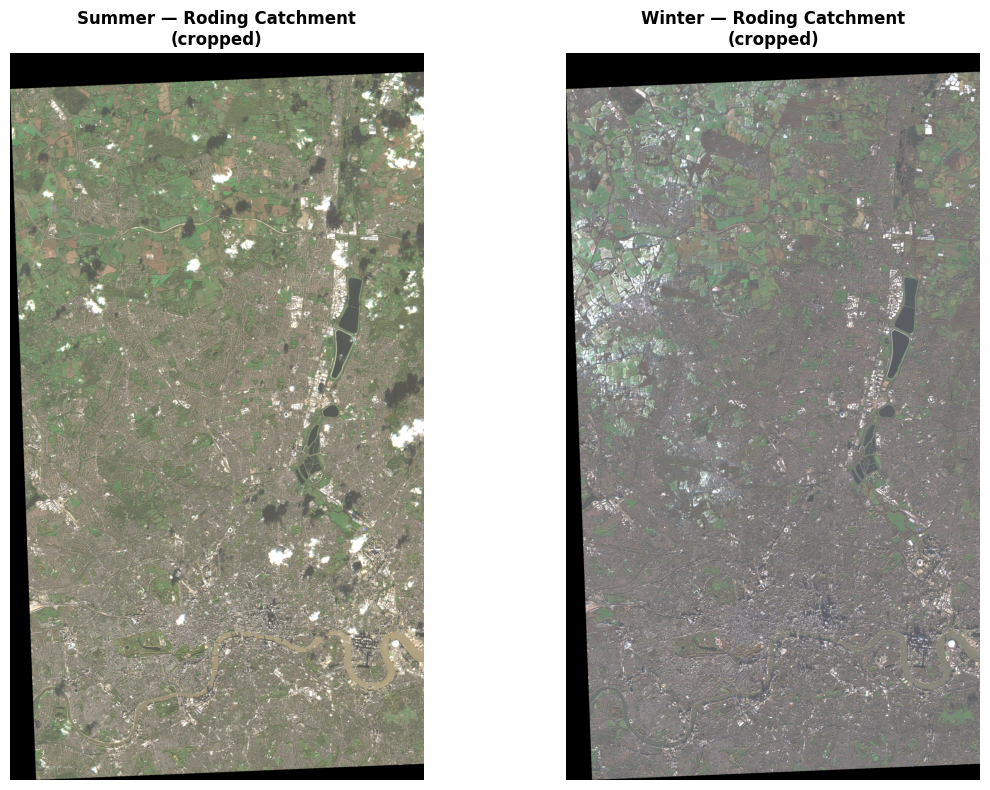

In [ ]:
# Crop bands to River Roding catchment bounding box

import rasterio
from rasterio.mask import mask as rio_mask
from shapely.geometry import box, mapping

# Roding catchment bounding box (WGS84)
RODING_BBOX = box(-0.25, 51.45, 0.35, 51.75)

def crop_band_to_bbox(safe_dir, band_name, bbox_geom):
    path = find_band(safe_dir, band_name)
    with rasterio.open(path) as src:
        # Reproject bbox to the band's CRS
        from rasterio.warp import transform_geom
        bbox_proj = transform_geom('EPSG:4326', src.crs,
                                   mapping(bbox_geom))
        cropped, transform = rio_mask(src, [bbox_proj],
                                      crop=True, nodata=0)
        arr = cropped[0].astype(np.float32)
        profile = src.profile.copy()
        profile.update({'transform': transform,
                        'width': arr.shape[1],
                        'height': arr.shape[0]})
    arr = np.clip(arr / 10000.0, 0, 1)
    return arr, profile

# Reload all bands cropped to study area
print("Cropping summer bands to Roding catchment...")
bands_summer = {}
for band in ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']:
    bands_summer[band], profile_summer = crop_band_to_bbox(
        summer_safe, band, RODING_BBOX)
    print(f"  {band}: {bands_summer[band].shape}")

print("\nCropping winter bands to Roding catchment...")
bands_winter = {}
for band in ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']:
    bands_winter[band], profile_winter = crop_band_to_bbox(
        winter_safe, band, RODING_BBOX)
    print(f"  {band}: {bands_winter[band].shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(make_rgb(bands_summer))
axes[0].set_title('Summer — Roding Catchment\n(cropped)', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(make_rgb(bands_winter))
axes[1].set_title('Winter — Roding Catchment\n(cropped)', fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Cell 5: Spectral Index Calculation

**Objective:** Compute NDVI, NDWI, and NDBI over the full catchment.

| Index | Formula | Interpretation for water quality |
|-------|---------|----------------------------------|
| NDVI  | (NIR − Red) / (NIR + Red) | Vegetation cover — inverse proxy for impervious area |
| NDWI  | (Green − NIR) / (Green + NIR) | Open water detection |
| NDBI  | (SWIR1 − NIR) / (SWIR1 + NIR) | Built-up / impervious surfaces — key EC predictor |

In [ ]:
cell5_start = time.time()

def compute_indices(bands):

    eps = 1e-8

    ndvi = (bands['B08'] - bands['B04']) / (bands['B08'] + bands['B04'] + eps)
    ndwi = (bands['B03'] - bands['B08']) / (bands['B03'] + bands['B08'] + eps)

    b11 = bands['B11']
    b08 = bands['B08']
    if b11.shape != b08.shape:
        from skimage.transform import resize
        b11 = resize(b11, b08.shape, order=1, anti_aliasing=True)

    ndbi = (b11 - b08) / (b11 + b08 + eps)

    return {'NDVI': ndvi, 'NDWI': ndwi, 'NDBI': ndbi}


indices_summer = compute_indices(bands_summer)
indices_winter = compute_indices(bands_winter)

print("Summer indices computed:")
for name, arr in indices_summer.items():
    print(f"  {name}: mean={arr.mean():.3f}, std={arr.std():.3f}")

print("\nWinter indices computed:")
for name, arr in indices_winter.items():
    print(f"  {name}: mean={arr.mean():.3f}, std={arr.std():.3f}")

Summer indices computed:
  NDVI: mean=0.264, std=0.188
  NDWI: mean=-0.263, std=0.166
  NDBI: mean=-0.073, std=0.122

Winter indices computed:
  NDVI: mean=0.214, std=0.166
  NDWI: mean=-0.216, std=0.152
  NDBI: mean=-0.076, std=0.133


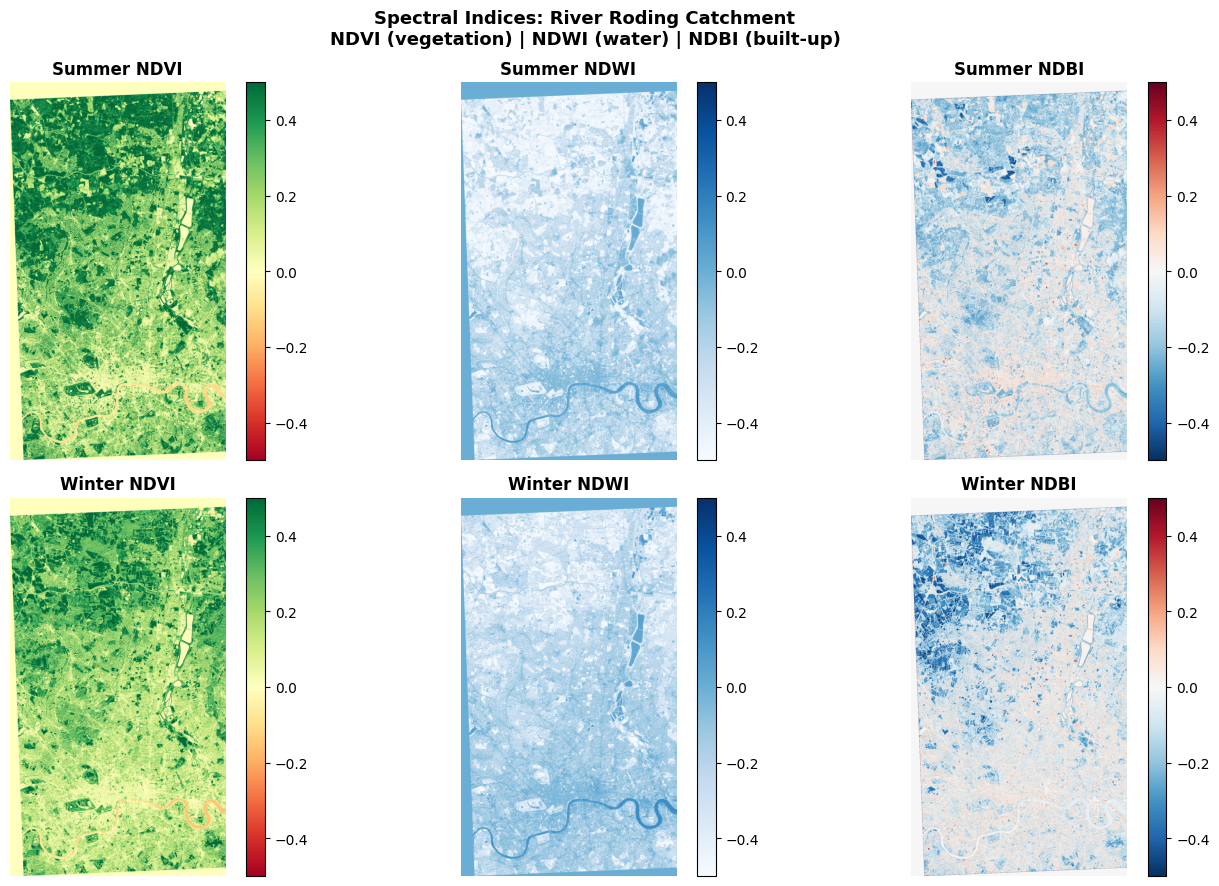

 Spectral Index Calculation completed:
   Duration : 0.3 min
   Energy   : 0.4 Wh
   Carbon   : 0.2 g CO2


In [ ]:
# Visualise indices over the catchment

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
cmaps = {'NDVI': 'RdYlGn', 'NDWI': 'Blues', 'NDBI': 'RdBu_r'}

for col, (name, cmap) in enumerate(cmaps.items()):
    for row, (season, indices) in enumerate(
            zip(['Summer', 'Winter'], [indices_summer, indices_winter])):
        im = axes[row, col].imshow(indices[name], cmap=cmap, vmin=-0.5, vmax=0.5)
        axes[row, col].set_title(f'{season} {name}', fontweight='bold')
        axes[row, col].axis('off')
        plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)

plt.suptitle('Spectral Indices: River Roding Catchment\n'
             'NDVI (vegetation) | NDWI (water) | NDBI (built-up)',
             fontsize=13,
             fontweight='bold',
             x=0.57)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'spectral_indices.png'),
            dpi=150, bbox_inches='tight')
plt.show()

track_phase("Spectral Index Calculation", cell5_start)

## Cell 6: Feature Extraction at Sampling Points

**Objective:** Extract Sentinel-2 spectral features at each of the 38 sampling locations.


**Features extracted per site:**
- Raw bands: B02, B03, B04, B08 (10m) and B11 (20m, resampled)
- Derived indices: NDVI, NDWI, NDBI
- Both summer and winter scenes → 2 × 8 = 16 spectral features per site
- Position proxy: distance rank (upstream → downstream)

In [ ]:
cell6_start = time.time()

import rasterio
from rasterio.transform import rowcol
from rasterio.warp import transform as warp_transform
import numpy as np
import pandas as pd

def sample_raster_at_points(band_array, profile, lons, lats):

    src_crs  = profile['crs']
    transform = profile['transform']

    xs, ys = warp_transform('EPSG:4326', src_crs,
                             list(lons), list(lats))

    values = []
    h, w = band_array.shape
    for x, y in zip(xs, ys):
        row, col = rowcol(transform, x, y)
        row = max(0, min(row, h - 1))
        col = max(0, min(col, w - 1))
        values.append(band_array[row, col])

    return np.array(values, dtype=np.float32)


print("Point sampling function loaded")

Point sampling function loaded


In [ ]:
# Extract features at all 38 locations
lons = df['lon'].values
lats = df['lat'].values

feature_rows = []

for season_label, bands, indices, profile in [
        ('summer', bands_summer, indices_summer, profile_summer),
        ('winter', bands_winter, indices_winter, profile_winter)
]:
    print(f"Sampling {season_label} bands...")
    row = {}

    for band_name in ['B02', 'B03', 'B04', 'B08', 'B11']:
        vals = sample_raster_at_points(bands[band_name], profile, lons, lats)
        row[f'{season_label}_{band_name}'] = vals
        print(f"  {band_name}: mean={vals.mean():.3f}")

    for idx_name in ['NDVI', 'NDWI', 'NDBI']:
        vals = sample_raster_at_points(indices[idx_name], profile, lons, lats)
        row[f'{season_label}_{idx_name}'] = vals
        print(f"  {idx_name}: mean={vals.mean():.3f}")

    feature_rows.append(row)

feat_dict = {}
for row in feature_rows:
    feat_dict.update(row)

df_features = pd.DataFrame(feat_dict)

df_features['distance_rank'] = df['lat'].rank(ascending=False).astype(int)

FEATURE_COLS_REDUCED = [
    'summer_NDVI', 'summer_NDWI', 'summer_NDBI',
    'winter_NDVI', 'winter_NDWI', 'winter_NDBI',
    'distance_rank'
]

df_ml = pd.concat([df.reset_index(drop=True),
                   df_features.reset_index(drop=True)], axis=1)

print(f"\nFeature matrix shape: {df_features.shape}")
print(f"Columns: {df_features.columns.tolist()}")
df_features.head()

Sampling summer bands...
  B02: mean=0.119
  B03: mean=0.144
  B04: mean=0.143
  B08: mean=0.306
  B11: mean=0.244
  NDVI: mean=0.328
  NDWI: mean=-0.327
  NDBI: mean=-0.076
Sampling winter bands...
  B02: mean=0.132
  B03: mean=0.146
  B04: mean=0.137
  B08: mean=0.350
  B11: mean=0.208
  NDVI: mean=0.398
  NDWI: mean=-0.374
  NDBI: mean=-0.172

Feature matrix shape: (38, 17)
Columns: ['summer_B02', 'summer_B03', 'summer_B04', 'summer_B08', 'summer_B11', 'summer_NDVI', 'summer_NDWI', 'summer_NDBI', 'winter_B02', 'winter_B03', 'winter_B04', 'winter_B08', 'winter_B11', 'winter_NDVI', 'winter_NDWI', 'winter_NDBI', 'distance_rank']


,summer_B02,summer_B03,summer_B04,summer_B08,summer_B11,summer_NDVI,summer_NDWI,summer_NDBI,winter_B02,winter_B03,winter_B04,winter_B08,winter_B11,winter_NDVI,winter_NDWI,winter_NDBI,distance_rank
0,0.1284,0.1560,0.1600,0.3470,0.2465,0.368836,-0.379722,-0.101107,0.1423,0.1666,0.1655,0.3008,0.2326,0.290157,-0.287120,-0.076540,6
1,0.1250,0.1534,0.1614,0.2328,0.2267,0.181126,-0.205593,0.040158,0.1400,0.1655,0.1421,0.4548,0.1909,0.523873,-0.466387,-0.304225,8
2,0.1141,0.1340,0.1414,0.1822,0.2562,0.126082,-0.152435,0.027640,0.1376,0.1658,0.1457,0.4656,0.2202,0.523311,-0.474818,-0.275991,12
3,0.1008,0.1247,0.1155,0.2954,0.2637,0.437819,-0.406332,-0.123644,0.1285,0.1307,0.1318,0.2536,0.2424,0.316035,-0.319802,-0.015197,18
4,0.1190,0.1503,0.1488,0.3764,0.2238,0.433359,-0.429277,-0.156928,0.1311,0.1312,0.1464,0.2688,0.1883,0.294798,-0.344000,-0.076194,21


In [ ]:
# Apply estuarine filter
# Exclude Thames backwash sites (EC > 1800) from training — same threshold as Cell 2.

EC_THRESHOLD = 1800
df_ml['estuarine'] = df_ml['EC_uS_cm'] > EC_THRESHOLD

df_fresh  = df_ml[~df_ml['estuarine']].reset_index(drop=True)
df_estuar = df_ml[ df_ml['estuarine']].reset_index(drop=True)

print(f"Freshwater sites (model training/CV) : {len(df_fresh)}")
print(f"Estuarine sites  (out-of-domain test): {len(df_estuar)}")

# Subsets with ICP data (Na available)
df_fresh_na = df_fresh.dropna(subset=['Na_ppm']).reset_index(drop=True)
print(f"Freshwater + Na data (ICP subset)    : {len(df_fresh_na)}")

# Feature column names (used throughout regression cells)
FEATURE_COLS = FEATURE_COLS_REDUCED
print(f"\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}")

track_phase("Feature Extraction", cell6_start,
            f"{len(FEATURE_COLS)} features × {len(df_ml)} sites")

Freshwater sites (model training/CV) : 31
Estuarine sites  (out-of-domain test): 7
Freshwater + Na data (ICP subset)    : 11

Features (7): ['summer_NDVI', 'summer_NDWI', 'summer_NDBI', 'winter_NDVI', 'winter_NDWI', 'winter_NDBI', 'distance_rank']
 Feature Extraction completed:
   Duration : 0.0 min
   Energy   : 0.0 Wh
   Carbon   : 0.0 g CO2


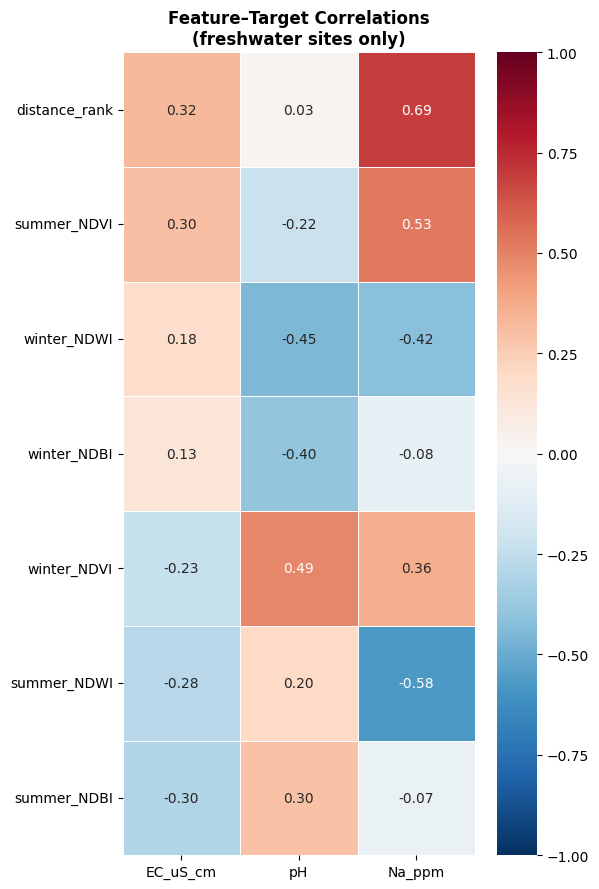

Top features correlated with EC:
distance_rank    0.322539
summer_NDBI      0.301584
summer_NDVI      0.298405
summer_NDWI      0.277293
winter_NDVI      0.227075
Name: EC_uS_cm, dtype: float64


In [ ]:
# features vs EC

import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = FEATURE_COLS + ['EC_uS_cm', 'pH', 'Na_ppm']
corr_data = df_fresh[corr_cols].dropna()
corr_matrix = corr_data.corr()

targets = ['EC_uS_cm', 'pH', 'Na_ppm']
corr_with_targets = corr_matrix[targets].drop(targets).sort_values('EC_uS_cm', ascending=False)

fig, ax = plt.subplots(figsize=(6, 9))
sns.heatmap(corr_with_targets, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature–Target Correlations\n(freshwater sites only)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'feature_correlation_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("Top features correlated with EC:")
print(corr_with_targets['EC_uS_cm'].abs().sort_values(ascending=False).head(5))

## Cell 7: Regression — Random Forest and Polynomial Baseline

**Objective:** Predict EC and Na from Sentinel-2 catchment features using:
1. **Polynomial Regression**
2. **Random Forest Regressor**

**Validation:** Leave-One-Out Cross-Validation (LOO-CV) is used instead of a fixed
train/test split because n=38 is too small to hold out a test set without losing
representativeness. LOO-CV is the standard approach for small geochemical datasets.

In [ ]:
cell7_start = time.time()

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

def run_loo_cv(model, X, y, model_name="Model"):
    loo = LeaveOneOut()
    y_pred_all = np.zeros(len(y))

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train         = y[train_idx]
        model.fit(X_train, y_train)
        y_pred_all[test_idx] = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y, y_pred_all))
    r2   = r2_score(y, y_pred_all)
    mae  = np.mean(np.abs(y - y_pred_all))

    print(f"{model_name}:")
    print(f"  R²   = {r2:.3f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE  = {mae:.2f}")

    return y_pred_all, {'r2': r2, 'rmse': rmse, 'mae': mae}

print("Regression functions loaded")

Regression functions loaded


In [ ]:
# Electrical Conductivity (EC) — n=38 freshwater sites

X_ec = df_fresh[FEATURE_COLS].values
y_ec = df_fresh['EC_uS_cm'].values

scaler_ec = StandardScaler()
X_ec_scaled = scaler_ec.fit_transform(X_ec)

print(f"EC model — X: {X_ec_scaled.shape}, y range: {y_ec.min():.0f}–{y_ec.max():.0f} µS/cm")
print("=" * 50)

# Polynomial Regression baseline
model_ridge_ec = Ridge(alpha=1.0)
y_pred_ridge_ec, metrics_ridge_ec = run_loo_cv(
    model_ridge_ec, X_ec_scaled, y_ec, "Ridge Regression (EC)")

print()

# Random Forest (main model)
model_rf_ec = RandomForestRegressor(
    n_estimators=200, max_depth=5,
    min_samples_leaf=3, random_state=42
)
y_pred_rf_ec, metrics_rf_ec = run_loo_cv(
    model_rf_ec, X_ec_scaled, y_ec, "Random Forest (EC)")

EC model — X: (31, 7), y range: 456–1110 µS/cm
Ridge Regression (EC):
  R²   = 0.255
  RMSE = 128.52
  MAE  = 107.72

Random Forest (EC):
  R²   = 0.170
  RMSE = 135.64
  MAE  = 111.86


In [ ]:
# Sodium (Na) — n=15 ICP-OES freshwater sites

X_na = df_fresh_na[FEATURE_COLS].values
y_na = df_fresh_na['Na_ppm'].values

scaler_na = StandardScaler()
X_na_scaled = scaler_na.fit_transform(X_na)

print(f"Na model  — X: {X_na_scaled.shape}, y range: {y_na.min():.1f}–{y_na.max():.1f} ppm")
print("=" * 50)

# Polynomial baseline
model_ridge_na = Ridge(alpha=1.0)
y_pred_ridge_na, metrics_ridge_na = run_loo_cv(
    model_ridge_na, X_na_scaled, y_na, "Ridge Regression (Na)")

print()

# Random Forest
model_rf_na = RandomForestRegressor(
    n_estimators=200, max_depth=4,
    min_samples_leaf=2, random_state=42
)
y_pred_rf_na, metrics_rf_na = run_loo_cv(
    model_rf_na, X_na_scaled, y_na, "Random Forest (Na)")

Na model  — X: (11, 7), y range: 17.7–60.1 ppm
Ridge Regression (Na):
  R²   = 0.009
  RMSE = 14.17
  MAE  = 11.51

Random Forest (Na):
  R²   = -0.048
  RMSE = 14.58
  MAE  = 12.03


In [ ]:
# pH — expected non-result
# pH is geologically buffered (carbonate system) — spectral features
# from Sentinel-2 should NOT predict it well.

X_ph = df_fresh[FEATURE_COLS].values
y_ph = df_fresh['pH'].values

scaler_ph = StandardScaler()
X_ph_scaled = scaler_ph.fit_transform(X_ph)

print(f"pH model  — X: {X_ph_scaled.shape}, y range: {y_ph.min():.2f}–{y_ph.max():.2f}")
print("=" * 50)
print("Expected: low R² — pH controlled by carbonate geology, not land cover")
print()

model_rf_ph = RandomForestRegressor(
    n_estimators=200, max_depth=5,
    min_samples_leaf=3, random_state=42
)
y_pred_rf_ph, metrics_rf_ph = run_loo_cv(
    model_rf_ph, X_ph_scaled, y_ph, "Random Forest (pH)")

track_phase("Regression Models (EC, Na, pH)", cell7_start)

pH model  — X: (31, 7), y range: 7.62–8.65
Expected: low R² — pH controlled by carbonate geology, not land cover

Random Forest (pH):
  R²   = -0.116
  RMSE = 0.25
  MAE  = 0.19
 Regression Models (EC, Na, pH) completed:
   Duration : 0.3 min
   Energy   : 0.3 Wh
   Carbon   : 0.2 g CO2


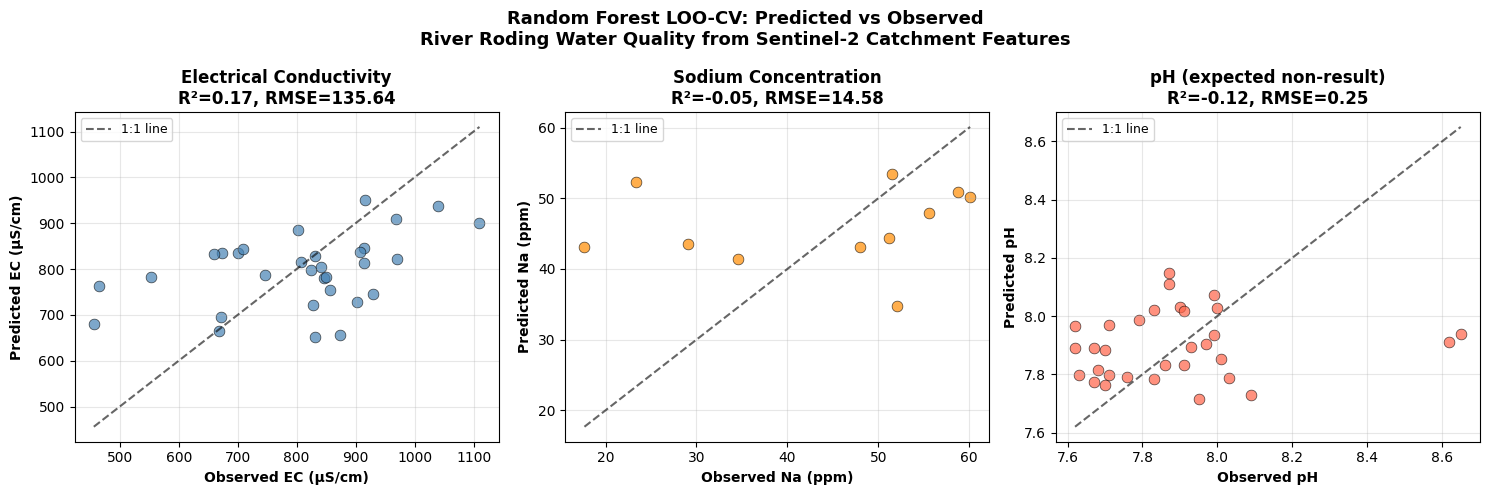

In [ ]:
# Predicted vs Observed plots

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_configs = [
    (y_ec, y_pred_rf_ec, metrics_rf_ec, 'EC (µS/cm)',
     'Electrical Conductivity', 'steelblue'),
    (y_na, y_pred_rf_na, metrics_rf_na, 'Na (ppm)',
     'Sodium Concentration', 'darkorange'),
    (y_ph, y_pred_rf_ph, metrics_rf_ph, 'pH',
     'pH (expected non-result)', 'tomato'),
]

for ax, (y_true, y_pred, metrics, unit, title, colour) in zip(axes, plot_configs):
    ax.scatter(y_true, y_pred, color=colour, alpha=0.7, s=60, edgecolors='k', lw=0.5)

    # Perfect prediction line
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', alpha=0.6, label='1:1 line')

    ax.set_xlabel(f'Observed {unit}', fontweight='bold')
    ax.set_ylabel(f'Predicted {unit}', fontweight='bold')
    ax.set_title(f'{title}\nR²={metrics["r2"]:.2f}, RMSE={metrics["rmse"]:.2f}',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Random Forest LOO-CV: Predicted vs Observed\n'
             'River Roding Water Quality from Sentinel-2 Catchment Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'predicted_vs_observed.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Performance summary table

summary = pd.DataFrame({
    'Target':  ['EC', 'EC', 'Na', 'Na', 'pH'],
    'Model': ['Ridge Regression', 'Random Forest',
          'Ridge Regression', 'Random Forest',
          'Random Forest'],
    'n':       [len(y_ec), len(y_ec),
                len(y_na), len(y_na),
                len(y_ph)],
    'R²': [metrics_ridge_ec['r2'], metrics_rf_ec['r2'],
       metrics_ridge_na['r2'], metrics_rf_na['r2'],
       metrics_rf_ph['r2']],
'RMSE': [metrics_ridge_ec['rmse'], metrics_rf_ec['rmse'],
       metrics_ridge_na['rmse'], metrics_rf_na['rmse'],
       metrics_rf_ph['rmse']],
'MAE': [metrics_ridge_ec['mae'], metrics_rf_ec['mae'],
       metrics_ridge_na['mae'], metrics_rf_na['mae'],
       metrics_rf_ph['mae']],
})

summary = summary.round(3)
print("\nModel Performance Summary (LOO-CV)")
print("=" * 55)
print(summary.to_string(index=False))
summary.to_csv(os.path.join(PROJECT_PATH, 'figures', 'model_performance.csv'), index=False)


Model Performance Summary (LOO-CV)
Target            Model  n     R²    RMSE     MAE
    EC Ridge Regression 31  0.255 128.520 107.719
    EC    Random Forest 31  0.170 135.641 111.863
    Na Ridge Regression 11  0.009  14.172  11.513
    Na    Random Forest 11 -0.048  14.576  12.030
    pH    Random Forest 31 -0.116   0.251   0.189


In [ ]:
# Spatial-only vs EO-only vs Combined EC models

EO_COLS = [c for c in FEATURE_COLS if c != 'distance_rank']
SPATIAL_COLS = ['distance_rank']
COMBINED_COLS = FEATURE_COLS

ec_comparison = {}

for label, cols in [
    ('Spatial only', SPATIAL_COLS),
    ('EO only', EO_COLS),
    ('Combined', COMBINED_COLS),
]:
    X = df_fresh[cols].values
    y = df_fresh['EC_uS_cm'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=3,
        random_state=42
    )

    y_pred, metrics = run_loo_cv(model, X_scaled, y, f"RF EC — {label}")
    ec_comparison[label] = metrics

RF EC — Spatial only:
  R²   = 0.191
  RMSE = 133.94
  MAE  = 112.07
RF EC — EO only:
  R²   = 0.015
  RMSE = 147.74
  MAE  = 122.49
RF EC — Combined:
  R²   = 0.170
  RMSE = 135.64
  MAE  = 111.86


## Cell 8: SHAP Explainability

**Objective:** Use SHAP (SHapley Additive exPlanations) to identify which Sentinel-2
features drive predictions for EC and Na.

**Expected findings:**
- Hypothesis: EC may be influenced by built-up and imperviousness proxies such as NDBI.
- Na: Similar pattern but weaker (smaller n)
- pH: No dominant feature — confirms carbonate buffering interpretation from water quality mapping project.

In [ ]:
cell8_start = time.time()

!pip install shap --quiet
import shap

model_rf_ec.fit(X_ec_scaled, y_ec)
model_rf_na.fit(X_na_scaled, y_na)
model_rf_ph.fit(X_ph_scaled, y_ph)

explainer_ec = shap.TreeExplainer(model_rf_ec)
shap_values_ec = explainer_ec.shap_values(X_ec_scaled)

explainer_na = shap.TreeExplainer(model_rf_na)
shap_values_na = explainer_na.shap_values(X_na_scaled)

explainer_ph = shap.TreeExplainer(model_rf_ph)
shap_values_ph = explainer_ph.shap_values(X_ph_scaled)

print("SHAP values computed")

SHAP values computed


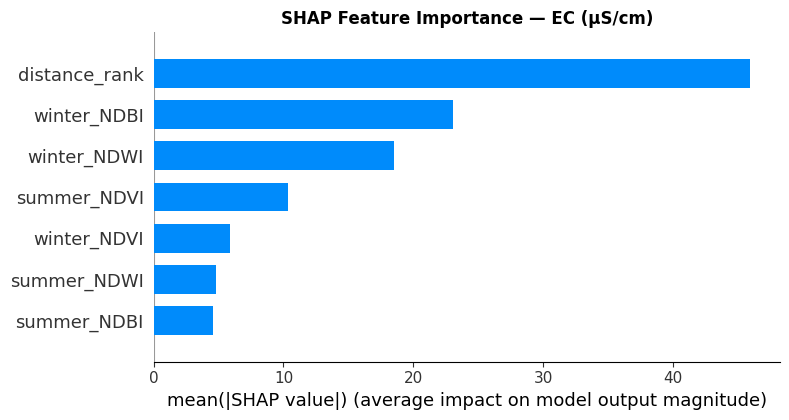

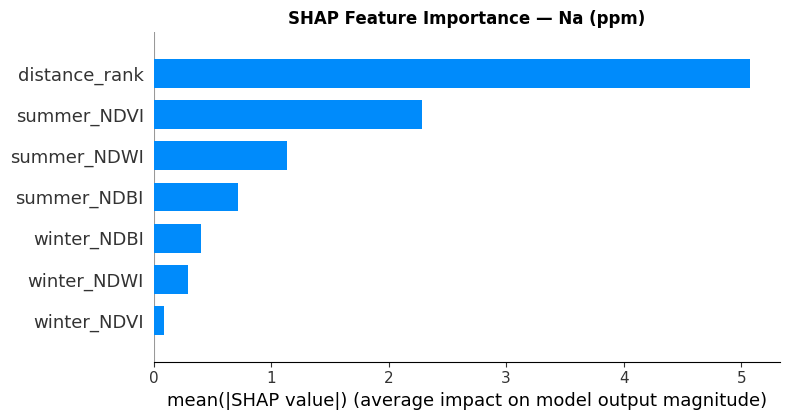

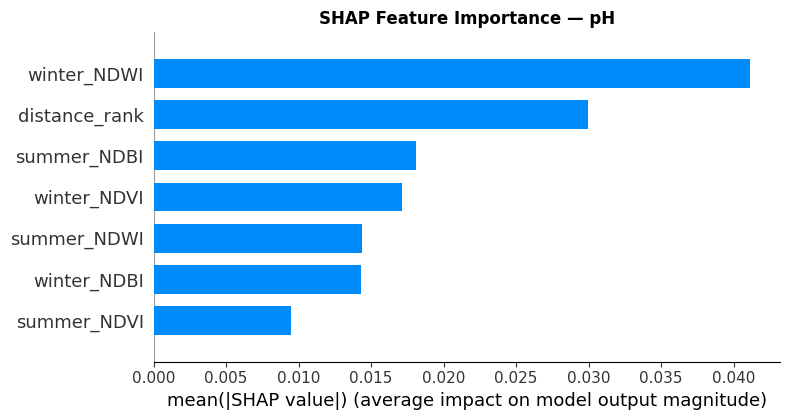

In [ ]:
# SHAP summary plots

for shap_vals, X_vals, title, filename in [
    (shap_values_ec, X_ec_scaled, 'EC (µS/cm)', 'shap_ec.png'),
    (shap_values_na, X_na_scaled, 'Na (ppm)', 'shap_na.png'),
    (shap_values_ph, X_ph_scaled, 'pH', 'shap_ph.png'),
]:

    plt.figure(figsize=(7, 5))

    shap.summary_plot(
        shap_vals,
        X_vals,
        feature_names=FEATURE_COLS,
        plot_type='bar',
        show=False
    )

    plt.title(
        f'SHAP Feature Importance — {title}',
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(PROJECT_PATH, 'figures', filename),
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

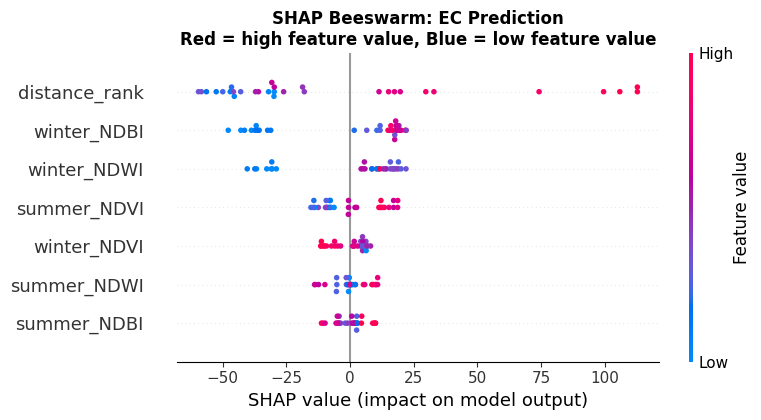

In [ ]:
# Beeswarm plot for EC

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_ec, X_ec_scaled,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title('SHAP Beeswarm: EC Prediction\n'
          'Red = high feature value, Blue = low feature value',
          fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'shap_beeswarm_ec.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 9: Estuarine Out-of-Domain Evaluation

**Objective:** Apply the freshwater-trained EC model to the estuarine sites and show
it fails — demonstrating the model correctly captures land-use driven chemistry but
cannot account for tidal mixing (a hydrological process invisible to Sentinel-2).

Out-of-domain evaluation — Estuarine sites (EC > 1800 µS/cm)
  n sites : 7
  R²      : -9.210  (freshwater model: 0.170)
  RMSE    : 2641 µS/cm  (freshwater: 136)

Interpretation: Model underpredicts estuarine EC because Thames backwash
(saline intrusion) is not captured by catchment land-cover features.
This confirms tidal mixing as a distinct control, consistent with GEOL0024.


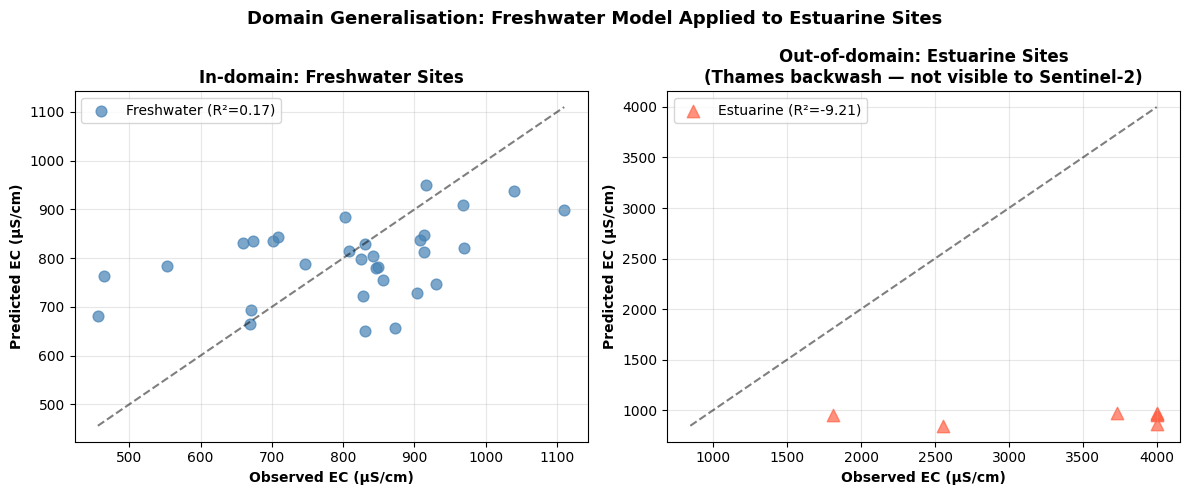

 Estuarine Out-of-Domain Evaluation completed:
   Duration : 0.0 min
   Energy   : 0.0 Wh
   Carbon   : 0.0 g CO2


In [ ]:
cell9_start = time.time()

# Apply freshwater EC model to estuarine sites
X_estuar = df_estuar[FEATURE_COLS].values
X_estuar_scaled = scaler_ec.transform(X_estuar)
y_estuar_true = df_estuar['EC_uS_cm'].values
y_estuar_pred = model_rf_ec.predict(X_estuar_scaled)

rmse_estuar = np.sqrt(mean_squared_error(y_estuar_true, y_estuar_pred))
r2_estuar   = r2_score(y_estuar_true, y_estuar_pred)

print("Out-of-domain evaluation — Estuarine sites (EC > 1800 µS/cm)")
print(f"  n sites : {len(y_estuar_true)}")
print(f"  R²      : {r2_estuar:.3f}  (freshwater model: {metrics_rf_ec['r2']:.3f})")
print(f"  RMSE    : {rmse_estuar:.0f} µS/cm  (freshwater: {metrics_rf_ec['rmse']:.0f})")
print()
print("Interpretation: Model underpredicts estuarine EC because Thames backwash")
print("(saline intrusion) is not captured by catchment land-cover features.")
print("This confirms tidal mixing as a distinct control, consistent with GEOL0024.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Freshwater performance
axes[0].scatter(y_ec, y_pred_rf_ec, color='steelblue', alpha=0.7,
                s=60, label=f'Freshwater (R²={metrics_rf_ec["r2"]:.2f})')
lims = [min(y_ec.min(), y_pred_rf_ec.min()),
        max(y_ec.max(), y_pred_rf_ec.max())]
axes[0].plot(lims, lims, 'k--', alpha=0.5)
axes[0].set_xlabel('Observed EC (µS/cm)', fontweight='bold')
axes[0].set_ylabel('Predicted EC (µS/cm)', fontweight='bold')
axes[0].set_title('In-domain: Freshwater Sites', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Estuarine failure
axes[1].scatter(y_estuar_true, y_estuar_pred, color='tomato', alpha=0.7,
                s=80, marker='^',
                label=f'Estuarine (R²={r2_estuar:.2f})')
all_lims = [min(y_estuar_true.min(), y_estuar_pred.min()),
            max(y_estuar_true.max(), y_estuar_pred.max())]
axes[1].plot(all_lims, all_lims, 'k--', alpha=0.5)
axes[1].set_xlabel('Observed EC (µS/cm)', fontweight='bold')
axes[1].set_ylabel('Predicted EC (µS/cm)', fontweight='bold')
axes[1].set_title('Out-of-domain: Estuarine Sites\n'
                  '(Thames backwash — not visible to Sentinel-2)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Domain Generalisation: Freshwater Model Applied to Estuarine Sites',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'estuarine_ood_evaluation.png'),
            dpi=150, bbox_inches='tight')
plt.show()

track_phase("Estuarine Out-of-Domain Evaluation", cell9_start)

## Cell 10: K-Means Unsupervised Classification of the Roding Catchment

**Objective:** Apply K-means clustering to Sentinel-2 spectral bands over the Roding
catchment to discover natural land-cover groups without labels.

In [ ]:
cell10_start = time.time()

# K-Means on Sentinel-2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

band_stack = np.dstack([
    bands_summer['B04'],
    bands_summer['B03'],
    bands_summer['B02'],
    bands_summer['B08'],
])

valid_data_mask = np.all(band_stack > 0, axis=2)

X_kmeans = band_stack[valid_data_mask].reshape((-1, 4))

print(f"Valid pixels for clustering: {X_kmeans.shape[0]:,}")
print(f"Features per pixel: {X_kmeans.shape[1]} (B04, B03, B02, B08)")

kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
kmeans.fit(X_kmeans)
labels = kmeans.labels_

labels_image = np.full(band_stack.shape[:2], -1, dtype=int)
labels_image[valid_data_mask] = labels

print(f"Cluster sizes: {dict(zip(*np.unique(labels, return_counts=True)))}")

Valid pixels for clustering: 6,464,658
Features per pixel: 4 (B04, B03, B02, B08)
Cluster sizes: {np.int32(0): np.int64(2273126), np.int32(1): np.int64(1481972), np.int32(2): np.int64(102873), np.int32(3): np.int64(2606687)}


Cluster centre reflectances (interpret land cover):
 Cluster |      Red |    Green |     Blue |      NIR | Likely class
----------------------------------------------------------------------
       0 |    0.144 |    0.139 |    0.125 |    0.197 | Suburban
       1 |    0.145 |    0.163 |    0.125 |    0.461 | Woodland/veg
       2 |    0.432 |    0.435 |    0.418 |    0.527 | Suburban
       3 |    0.169 |    0.167 |    0.143 |    0.301 | Suburban


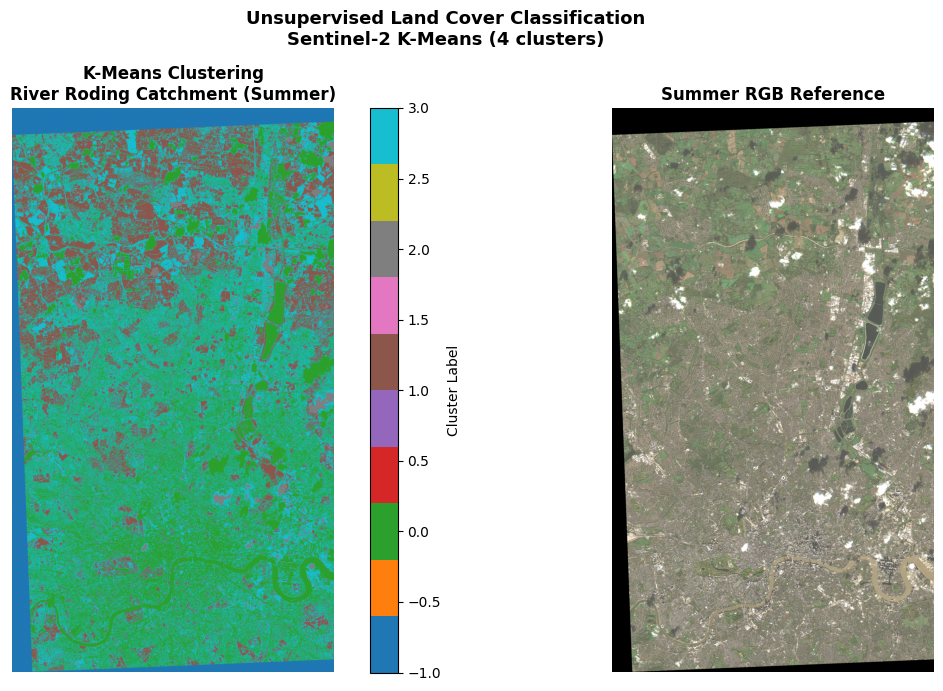

 K-Means Unsupervised Clustering completed:
   Duration : 0.5 min
   Energy   : 0.7 Wh
   Carbon   : 0.3 g CO2


In [ ]:
# Interpret clusters using cluster centre spectral values

centres = kmeans.cluster_centers_
band_names = ['Red(B04)', 'Green(B03)', 'Blue(B02)', 'NIR(B08)']

print("Cluster centre reflectances (interpret land cover):")
print(f"{'Cluster':>8} | {'Red':>8} | {'Green':>8} | {'Blue':>8} | {'NIR':>8} | Likely class")
print("-" * 70)
for i, c in enumerate(centres):
    ndvi = (c[3] - c[0]) / (c[3] + c[0] + 1e-8)
    label = ('Woodland/veg' if ndvi > 0.3
             else 'Water' if c[0] < 0.05 and c[1] < 0.05
             else 'Urban/impervious' if c[0] > c[3]
             else 'Suburban')
    print(f"{i:>8} | {c[0]:>8.3f} | {c[1]:>8.3f} | {c[2]:>8.3f} | {c[3]:>8.3f} | {label}")

CLUSTER_NAMES = {-1: 'No data', 0: 'Cluster 0', 1: 'Cluster 1',
                  2: 'Cluster 2', 3: 'Cluster 3'}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

im = axes[0].imshow(labels_image, cmap='tab10', vmin=-1, vmax=3)
axes[0].set_title('K-Means Clustering\nRiver Roding Catchment (Summer)',
                   fontweight='bold')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], label='Cluster Label')

axes[1].imshow(make_rgb(bands_summer))
axes[1].set_title('Summer RGB Reference', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Unsupervised Land Cover Classification\nSentinel-2 K-Means (4 clusters)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'kmeans_landcover.png'),
            dpi=150, bbox_inches='tight')
plt.show()

track_phase("K-Means Unsupervised Clustering", cell10_start)

/tmp/ipykernel_14260/2675602595.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=[f'C{i}' for i in range(4)])


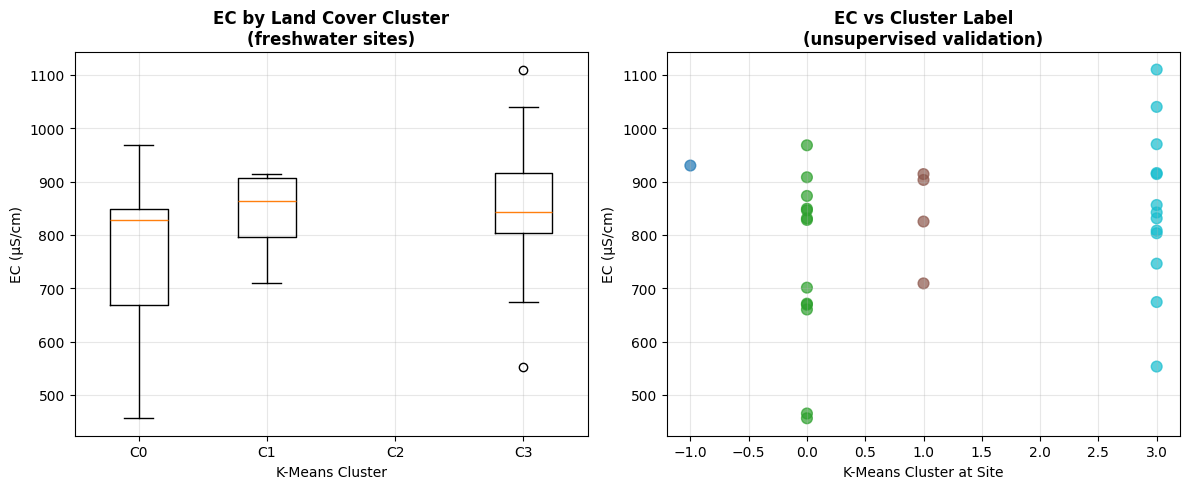

Mean EC by cluster:
kmeans_cluster
-1    930.0
 0    748.0
 1    838.0
 3    851.0
Name: EC_uS_cm, dtype: float64


In [ ]:
# Link clusters to water quality gradient

cluster_at_sites = sample_raster_at_points(
    labels_image.astype(np.float32), profile_summer,
    df_fresh['lon'].values, df_fresh['lat'].values
).astype(int)

df_fresh_plot = df_fresh.copy()
df_fresh_plot['kmeans_cluster'] = cluster_at_sites

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

groups = [df_fresh_plot[df_fresh_plot['kmeans_cluster'] == c]['EC_uS_cm'].values
          for c in range(4)]
axes[0].boxplot(groups, labels=[f'C{i}' for i in range(4)])
axes[0].set_xlabel('K-Means Cluster')
axes[0].set_ylabel('EC (µS/cm)')
axes[0].set_title('EC by Land Cover Cluster\n(freshwater sites)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(cluster_at_sites, df_fresh['EC_uS_cm'].values,
                alpha=0.7, s=60, c=cluster_at_sites, cmap='tab10')
axes[1].set_xlabel('K-Means Cluster at Site')
axes[1].set_ylabel('EC (µS/cm)')
axes[1].set_title('EC vs Cluster Label\n(unsupervised validation)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'kmeans_vs_ec.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("Mean EC by cluster:")
print(df_fresh_plot.groupby('kmeans_cluster')['EC_uS_cm'].mean().round(0))

## Cell 11: Seasonal Comparison — Summer vs Winter

**Objective:** Compare model performance between summer (low-flow) and winter
(high-flow) scenes. This tests whether land-cover features predict EC better under
one hydrological condition than the other.

**Expected finding:** Summer model should perform better because:
- Lower flow → ionic load more concentrated, more predictable from land cover
- Winter → dilution from rainfall reduces the land-cover signal

In [ ]:
cell11_start = time.time()

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# summer only, winter only combined
SUMMER_COLS = ['summer_NDVI', 'summer_NDWI', 'summer_NDBI']
WINTER_COLS = ['winter_NDVI', 'winter_NDWI', 'winter_NDBI']

print(f"Summer features: {len(SUMMER_COLS)}")
print(f"Winter features: {len(WINTER_COLS)}")
print(f"Combined features: {len(FEATURE_COLS)}")

results_seasonal = {}

for label, cols in [
    ('Summer only', SUMMER_COLS),
    ('Winter only', WINTER_COLS),
    ('Combined',    FEATURE_COLS),
]:
    X = df_fresh[cols].values
    y = df_fresh['EC_uS_cm'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = RandomForestRegressor(
        n_estimators=200, max_depth=5,
        min_samples_leaf=3, random_state=42
    )

    loo = LeaveOneOut()
    y_pred = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X_scaled):
        model.fit(X_scaled[train_idx], y[train_idx])
        y_pred[test_idx] = model.predict(X_scaled[test_idx])

    r2   = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    results_seasonal[label] = {'R2': r2, 'RMSE': rmse, 'y_pred': y_pred}
    print(f"{label:15s}: R²={r2:.3f}, RMSE={rmse:.1f} µS/cm")

track_phase("Seasonal Comparison", cell11_start)

Summer features: 3
Winter features: 3
Combined features: 7
Summer only    : R²=0.057, RMSE=144.5 µS/cm
Winter only    : R²=-0.113, RMSE=157.1 µS/cm
Combined       : R²=0.170, RMSE=135.6 µS/cm
 Seasonal Comparison completed:
   Duration : 0.3 min
   Energy   : 0.5 Wh
   Carbon   : 0.2 g CO2


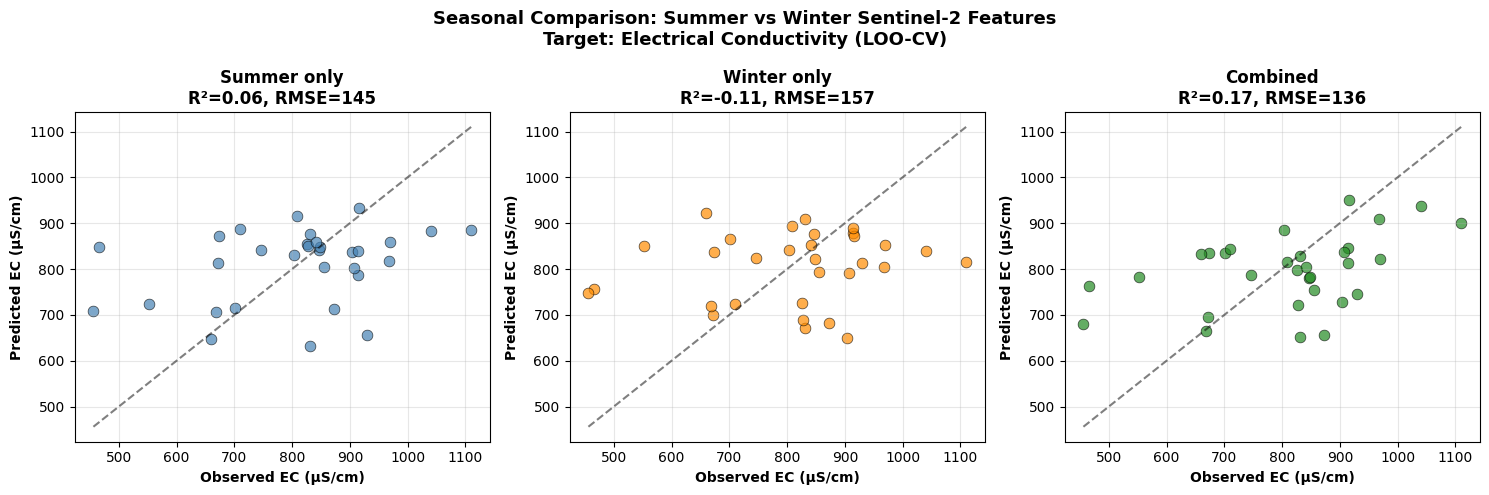

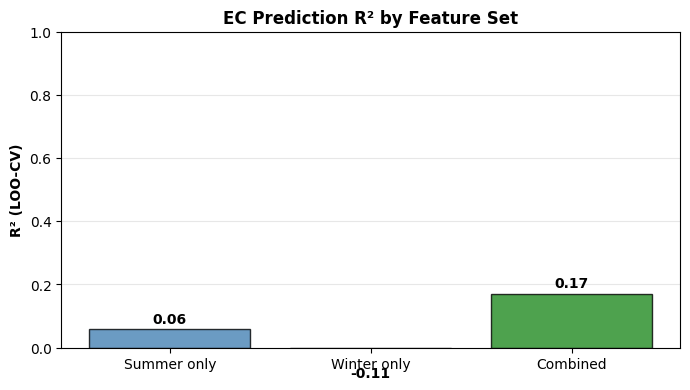

In [ ]:
# Seasonal comparison plot

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
y_ec = df_fresh['EC_uS_cm'].values
colours = ['steelblue', 'darkorange', 'forestgreen']

for ax, (label, res), colour in zip(axes, results_seasonal.items(), colours):
    ax.scatter(y_ec, res['y_pred'], color=colour, alpha=0.7, s=60,
               edgecolors='k', lw=0.5)
    lims = [min(y_ec.min(), res['y_pred'].min()),
            max(y_ec.max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel('Observed EC (µS/cm)', fontweight='bold')
    ax.set_ylabel('Predicted EC (µS/cm)', fontweight='bold')
    ax.set_title(f'{label}\nR²={res["R2"]:.2f}, RMSE={res["RMSE"]:.0f}',
                 fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Seasonal Comparison: Summer vs Winter Sentinel-2 Features\n'
             'Target: Electrical Conductivity (LOO-CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'seasonal_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Summary bar chart
fig, ax = plt.subplots(figsize=(7, 4))
labels_s = list(results_seasonal.keys())
r2_vals  = [results_seasonal[l]['R2']   for l in labels_s]
rmse_vals = [results_seasonal[l]['RMSE'] for l in labels_s]

x = np.arange(len(labels_s))
bars = ax.bar(x, r2_vals, color=colours, alpha=0.8, edgecolor='k')
ax.set_xticks(x)
ax.set_xticklabels(labels_s)
ax.set_ylabel('R² (LOO-CV)', fontweight='bold')
ax.set_title('EC Prediction R² by Feature Set', fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'seasonal_r2_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 12: Environmental Cost Assessment

**Objective:** Report the total computational carbon footprint of the project
and compare with the equivalent traditional field survey cost.

**Baseline:** Fieldwork involved two sampling campaigns along the
Roding corridor (Loughton to Barking, ~25 km). Estimated travel: 60 km round
trip × 2 seasons × 0.21 kg CO₂/km (car) = ~25 kg CO₂.


 ENVIRONMENTAL IMPACT REPORT
Total project duration : 0.1 hours
Total energy consumed  : 6 Wh
ML pipeline carbon     : 3 g CO2
Traditional fieldwork  : 25000 g CO2
Carbon saving          : >99%


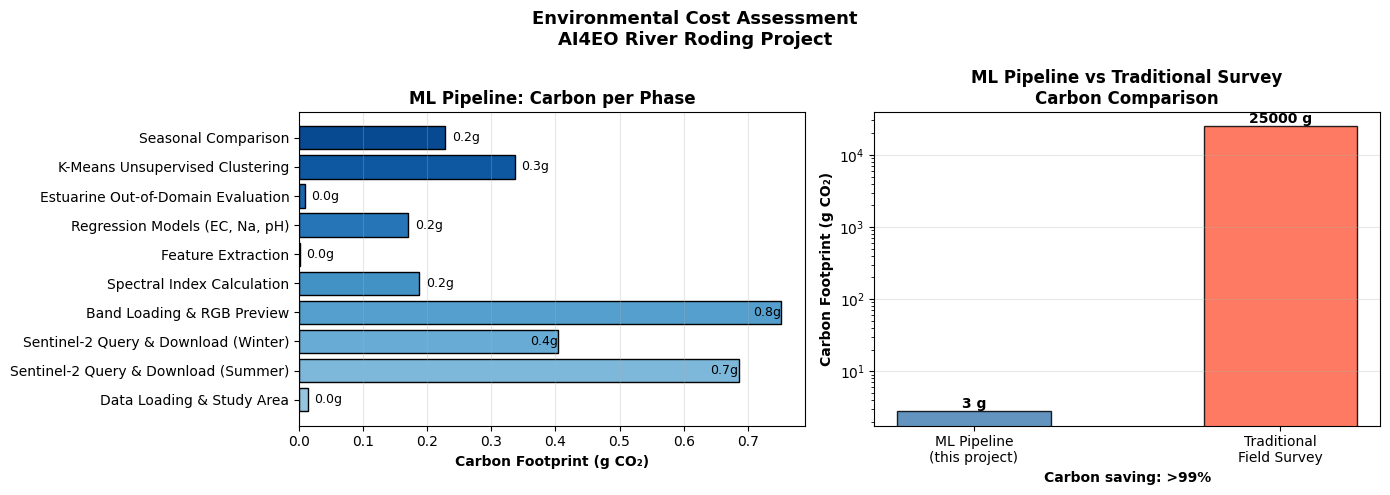


Total ML pipeline carbon: 2.8 g CO₂
Traditional field survey : 25000 g CO₂
Carbon saving            : >99%


In [ ]:
# environmental cost report
env_tracker.generate_report()

import matplotlib.pyplot as plt
import numpy as np

phases    = [log['phase']            for log in env_tracker.energy_logs]
carbon_g  = [log['carbon_kg_co2']*1000 for log in env_tracker.energy_logs]
duration  = [log['duration_minutes']  for log in env_tracker.energy_logs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colours = plt.cm.Blues(np.linspace(0.4, 0.9, len(phases)))
bars = axes[0].barh(phases, carbon_g, color=colours, edgecolor='k')
axes[0].set_xlabel('Carbon Footprint (g CO₂)', fontweight='bold')
axes[0].set_title('ML Pipeline: Carbon per Phase', fontweight='bold')
for bar, val in zip(bars, carbon_g):

    if val >= 0.4:
        x_pos = bar.get_width()
        ha_pos = 'right'
    else:
        x_pos = bar.get_width() + 0.01
        ha_pos = 'left'

    axes[0].text(x_pos,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}g',
                 va='center',
                 ha=ha_pos,
                 fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')

total_ml_g   = sum(carbon_g)
field_g      = 25000
categories   = ['ML Pipeline\n(this project)', 'Traditional\nField Survey']
values       = [total_ml_g, field_g]
bar_colours  = ['steelblue', 'tomato']

bars2 = axes[1].bar(categories, values, color=bar_colours, alpha=0.85,
                    edgecolor='k', width=0.5)
axes[1].set_ylabel('Carbon Footprint (g CO₂)', fontweight='bold')
axes[1].set_title('ML Pipeline vs Traditional Survey\nCarbon Comparison',
                  fontweight='bold')
axes[1].set_yscale('log')
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val,
                 f'{val:.0f} g',
                 ha='center',
                 va='bottom',
                 fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

saving_pct = (field_g - total_ml_g) / field_g * 100
axes[1].set_xlabel('Carbon saving: >99%', fontweight='bold')

plt.suptitle('Environmental Cost Assessment\nAI4EO River Roding Project',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'figures', 'environmental_cost.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal ML pipeline carbon: {total_ml_g:.1f} g CO₂")
print(f"Traditional field survey : {field_g:.0f} g CO₂")
print("Carbon saving            : >99%")